In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('__file__'), '..', 'utils')))
import os
import pickle
import itertools
import numpy as np
import numpy.ma as ma
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

from models import LinearModel

In [2]:
USE_ENSEMBLES          = True
SEEDS                  = [42, 43, 44, 45, 46]
# R2_THRESHOLD           = 0.1    # min mean R² for permutation importance
# CONSISTENCY_THRESHOLD  = 0.05   # lower threshold — include more neurons in consistency
N_PERM_REPEATS         = 5

# Set to False to skip recomputation and load saved results from disk instead.
RUN_EVAL        = True
RUN_IMPORTANCE  = True
RUN_CONSISTENCY = True

if USE_ENSEMBLES:
    R2_THRESHOLD           = 0.2    # min mean R² for permutation importance
    CONSISTENCY_THRESHOLD  = 0.1   # lower threshold — include more ensembles in consistency
else:
    R2_THRESHOLD           = 0.2    # min mean R² for permutation importance
    CONSISTENCY_THRESHOLD  = 0.1   # lower threshold — include more neurons in consistency

mode_str    = "ensembles" if USE_ENSEMBLES else "spikes"
prefix_name = "E" if USE_ENSEMBLES else "U"
models_root = f"../models/linear/{mode_str}"
splits_dir  = "../splits"
output_dir  = f"../outputs/linear/{mode_str}_multiseed"
cache_path  = f"../outputs/session_dataset_{mode_str}.pkl"
os.makedirs(output_dir, exist_ok=True)

unit_label    = "ensemble" if USE_ENSEMBLES else "neuron"
unit_label_pl = unit_label + "s"

print(f"mode={mode_str}, seeds={SEEDS}")
print(f"RUN_EVAL={RUN_EVAL}, RUN_IMPORTANCE={RUN_IMPORTANCE}, RUN_CONSISTENCY={RUN_CONSISTENCY}")
print(f"R2_THRESHOLD={R2_THRESHOLD}, CONSISTENCY_THRESHOLD={CONSISTENCY_THRESHOLD}")

mode=ensembles, seeds=[42, 43, 44, 45, 46]
RUN_EVAL=True, RUN_IMPORTANCE=True, RUN_CONSISTENCY=True
R2_THRESHOLD=0.2, CONSISTENCY_THRESHOLD=0.1


In [3]:
# ── Load raw data ──────────────────────────────────────────────────────────
if any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]) and not os.path.exists(cache_path):
    base = "../outputs/glm_input_data/"

    beh_vals = np.load(os.path.join(base, "behavior_glm_input.npy"), allow_pickle=True)
    beh_idx  = np.load(os.path.join(base, "behavior_glm_input_index.npy"), allow_pickle=True)
    beh_cols = np.load(os.path.join(base, "behavior_glm_input_columns.npy"), allow_pickle=True)

    spk_vals = np.load(os.path.join(base, "fr_full.npy"))
    spk_idx  = np.load(os.path.join(base, "fr_full_index.npy"), allow_pickle=True)
    spk_cols = np.load(os.path.join(base, "fr_full_columns.npy"), allow_pickle=True)

    ensembles_values = np.load(os.path.join(base, "ensembles.npy"))

    try:
        beh_index = pd.MultiIndex.from_tuples(beh_idx, names=behavior_glm_input.index.names)
    except Exception:
        beh_index = pd.Index(beh_idx)

    try:
        spk_index = pd.MultiIndex.from_tuples(spk_idx, names=fr_first7.index.names)
    except Exception:
        spk_index = pd.Index(spk_idx)

    behavior_glm_loaded = pd.DataFrame(beh_vals, index=beh_index, columns=beh_cols)
    spikes_loaded       = pd.DataFrame(spk_vals, index=spk_index, columns=spk_cols)

    print("behavior_glm_loaded", behavior_glm_loaded.shape)
    print("spikes_loaded",       spikes_loaded.shape)
else:
    print("Skipping raw data load (cache exists or all RUN_* flags are False)")


Skipping raw data load (cache exists or all RUN_* flags are False)


In [4]:
# ── Preprocessing ──────────────────────────────────────────────────────────
if any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]) and not os.path.exists(cache_path):
    spikes_loaded.index = pd.MultiIndex.from_tuples(
        spikes_loaded.index.map(lambda t: (t[0], t[1] // 40000 - 1))
    )

    spikes_unique_trials = set(idx[0] for idx in spikes_loaded.index)
    behavior_glm_loaded  = behavior_glm_loaded[
        behavior_glm_loaded.index.map(lambda t: t[0] in spikes_unique_trials)
    ]

    non_nan_rows        = behavior_glm_loaded.index[~behavior_glm_loaded.isna().any(axis=1)]
    behavior_glm_loaded = behavior_glm_loaded.loc[non_nan_rows]
    spikes_loaded       = spikes_loaded.loc[non_nan_rows]

    behavior_glm_loaded = behavior_glm_loaded.drop("track_zone", axis=1)

    session_ids = behavior_glm_loaded.index.map(lambda x: x[0]).unique()
    print(f"{len(session_ids)} sessions")
else:
    print("Skipping preprocessing (cache exists or all RUN_* flags are False)")


Skipping preprocessing (cache exists or all RUN_* flags are False)


In [5]:
# ── Feature columns ─────────────────────────────────────────────────────────
action_enc_cols = [
    'frame_raw_500msMedian',                  # forward_velocity
    'frame_raw_abs_acc_500msMedian',          # forward_acceleration
    'frame_YawPitch_abs_vel_sum_500msMedian', # off_rotation_velocity
    'frame_YawPitch_abs_acc_sum_500msMedian', # off_rotation_acceleration
    'head_angle_vel',
    'head_angle',
    'movement_energy_smooth5',                # movement_energy
    'upcoming_choice',
    'reward_window',
    'lick_detected',
]
state_enc_cols = [
    'cue_visible',
]

zone_values      = sorted(behavior_glm_loaded['track_zone_int'].dropna().unique().astype(int))
zone_onehot_cols = [f'track_zone_{z}' for z in zone_values]
for z in zone_values:
    behavior_glm_loaded[f'track_zone_{z}'] = (behavior_glm_loaded['track_zone_int'] == z).astype(float)

all_feat_cols = action_enc_cols + state_enc_cols + zone_onehot_cols
print(f"{len(all_feat_cols)} input features ({len(action_enc_cols)} action + {len(state_enc_cols)} state + {len(zone_onehot_cols)} zone)")

NameError: name 'behavior_glm_loaded' is not defined

In [ ]:
# ── Build / load session dataset (cached on disk) ──────────────────────────
if os.path.exists(cache_path):
    with open(cache_path, 'rb') as f:
        session_dataset_singles = pickle.load(f)
    session_ids = pd.Index(list(session_dataset_singles.keys()))
    print(f"Loaded dataset from cache: {cache_path}")
elif not any([RUN_EVAL, RUN_IMPORTANCE, RUN_CONSISTENCY]):
    raise FileNotFoundError(
        f"Cache not found: {cache_path}\n"
        "Set at least one RUN_* flag to True to build the cache first."
    )
else:
    session_dataset_singles = {}
    for session_id in session_ids:
        session_mask   = behavior_glm_loaded.index.map(lambda x: x[0]) == session_id
        beh            = behavior_glm_loaded[session_mask]
        spikes_session = spikes_loaded[session_mask]

        for col in action_enc_cols + state_enc_cols:
            if col in beh.columns:
                beh.loc[:, col] = beh[col].astype(float)
                mean_val = beh[col].mean()
                std_val  = beh[col].std() + 1e-8
                if std_val != 0:
                    beh.loc[:, col] = (beh[col] - mean_val) / std_val

        spikes_session = spikes_session.astype(float)
        if USE_ENSEMBLES:
            spikes_values = spikes_session.values
            new_spikes_session = pd.DataFrame(index=spikes_session.index)
            for i in range(ensembles_values.shape[1]):
                new_spikes_session[f'ensemble_{i}'] = spikes_values @ ensembles_values[:, i]
            spikes_session = new_spikes_session

        label_stds = []
        for col in spikes_session.columns:
            mean_val = spikes_session[col].mean()
            std_val  = spikes_session[col].std() + 1e-8
            label_stds.append(std_val)
            if std_val != 0:
                spikes_session[col] = (spikes_session[col] - mean_val) / std_val

        data_by_trial, labels_by_trial = {}, {}
        for trial_id in beh["trial_id"].unique():
            trial_mask                = beh["trial_id"] == trial_id
            data_by_trial[trial_id]   = beh.loc[trial_mask, all_feat_cols].values.astype(np.float16)
            labels_by_trial[trial_id] = spikes_session.loc[trial_mask].values.astype(np.float16)

        session_dataset_singles[session_id] = {
            "data":       data_by_trial,
            "labels":     labels_by_trial,
            "label_stds": label_stds,
        }

    with open(cache_path, 'wb') as f:
        pickle.dump(session_dataset_singles, f)
    print(f"Dataset built and cached to {cache_path}")


Loaded dataset from cache: ./outputs/session_dataset_ensembles.pkl


In [ ]:
# ── Model config ────────────────────────────────────────────────────────────
input_size   = len(all_feat_cols)
output_size  = 1
num_sessions = len(session_ids)
num_neurons  = len(next(iter(session_dataset_singles.values()))['label_stds'])

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"input_size={input_size}, sessions={num_sessions}, neurons={num_neurons}, device={device}")


input_size=13, sessions=29, neurons=23, device=cuda


In [ ]:
# ── Multi-seed evaluation: MSE and R² ─────────────────────────────────────
# Each seed uses its own split. Results: (n_seeds, n_sessions, n_neurons)
if RUN_EVAL:
    all_mse = np.full((len(SEEDS), num_sessions, num_neurons), np.nan)
    all_r2  = np.full((len(SEEDS), num_sessions, num_neurons), np.nan)

    for seed_idx, seed in enumerate(SEEDS):
        split_path = os.path.join(splits_dir, f"split_seed{seed}.npy")
        test_indices_by_session = np.load(split_path, allow_pickle=True).item()
        models_dir = os.path.join(models_root, f"seed{seed}")

        for test_idx, test_session in enumerate(session_ids):
            session_data   = session_dataset_singles[test_session]["data"]
            session_labels = session_dataset_singles[test_session]["labels"]
            test_idx_      = test_indices_by_session[test_session]

            test_data = torch.tensor(
                np.concatenate([session_data[idx]   for idx in test_idx_], axis=0),
                dtype=torch.float32).to(device)
            test_labels_np = np.concatenate(
                [session_labels[idx] for idx in test_idx_], axis=0)

            for neuron_idx in range(num_neurons):
                mpath = os.path.join(models_dir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue
                model = LinearModel(input_size, output_size).to(device)
                model.load_state_dict(torch.load(mpath, map_location=device))
                model.eval()
                with torch.no_grad():
                    _, preds = model(test_data)
                    preds_np = preds.squeeze().cpu().numpy()
                actual = test_labels_np[:, neuron_idx]
                all_mse[seed_idx, test_idx, neuron_idx] = mean_squared_error(actual, preds_np)
                if np.var(actual) > 1e-8:
                    all_r2[seed_idx, test_idx, neuron_idx] = r2_score(actual, preds_np)
                del model

            del test_data, test_labels_np
            torch.cuda.empty_cache()

        print(f"Seed {seed} done.")

    np.save(os.path.join(output_dir, "all_mse.npy"), all_mse)
    np.save(os.path.join(output_dir, "all_r2.npy"),  all_r2)
    print("Saved all_mse.npy and all_r2.npy")


Seed 42 done.
Seed 43 done.
Seed 44 done.
Seed 45 done.
Seed 46 done.
Saved all_mse.npy and all_r2.npy


In [ ]:
# ── Reload saved metrics (skip eval loop above if already run) ─────────────
all_mse = np.load(os.path.join(output_dir, "all_mse.npy"))
all_r2  = np.load(os.path.join(output_dir, "all_r2.npy"))

In [ ]:
# ── Mask silent neurons + compute seed-averaged metrics ────────────────────
mask = np.zeros((num_sessions, num_neurons), dtype=bool)
for i, session_id in enumerate(session_ids):
    for j, std in enumerate(session_dataset_singles[session_id]["label_stds"]):
        if std < 1e-3:
            mask[i, j] = True


In [ ]:
all_r2_masked  = all_r2.copy().astype(float)
all_mse_masked = all_mse.copy().astype(float)

# Expand mask to (seeds, sessions, neurons) and apply
mask_3d = np.broadcast_to(mask, all_r2.shape)
all_r2_masked[mask_3d]  = np.nan
all_mse_masked[mask_3d] = np.nan

print(f"NaNs introduced: {np.isnan(all_r2_masked).sum()}")

# Aggregate across seeds (axis=0)
with np.errstate(all='ignore'):
    mean_r2    = np.nanmean(all_r2_masked,    axis=0)
    std_r2     = np.nanstd(all_r2_masked,     axis=0)
    median_r2  = np.nanmedian(all_r2_masked,  axis=0)
    mean_mse   = np.nanmean(all_mse_masked,   axis=0)
    std_mse    = np.nanstd(all_mse_masked,    axis=0)
    median_mse = np.nanmedian(all_mse_masked, axis=0)

print(f"Valid pairs: {(~mask).sum()}")
print(f"Mean R²   (seed-avg): {np.nanmean(mean_r2[~mask]):.3f} \u00b1 {np.nanstd(mean_r2[~mask]):.3f}")
print(f"Median R² (seed-avg): {np.nanmedian(median_r2[~mask]):.3f} \u00b1 {np.nanstd(median_r2[~mask]):.3f}")
print(f"Mean MSE  (seed-avg): {np.nanmean(mean_mse[~mask]):.3f} \u00b1 {np.nanstd(mean_mse[~mask]):.3f}")
print(f"Median MSE(seed-avg): {np.nanmedian(median_mse[~mask]):.3f} \u00b1 {np.nanstd(median_mse[~mask]):.3f}")


NaNs introduced: 0
Valid pairs: 667
Mean R²   (seed-avg): -0.095 ± 0.035
Median R² (seed-avg): -0.087 ± 0.038
Mean MSE  (seed-avg): 1.097 ± 0.074
Median MSE(seed-avg): 1.083 ± 0.091


In [ ]:
flat_r2 = mean_r2[~mask]
print(f"Catastrophic pairs (R² < -1000): {(flat_r2 < -1000).sum()}")
print(f"Median of valid pairs: {np.nanmedian(flat_r2):.3f}")
print(f"Without catastrophic: {np.nanmean(flat_r2[flat_r2 > -1000]):.3f}")


Catastrophic pairs (R² < -1000): 0
Median of valid pairs: -0.095
Without catastrophic: -0.095


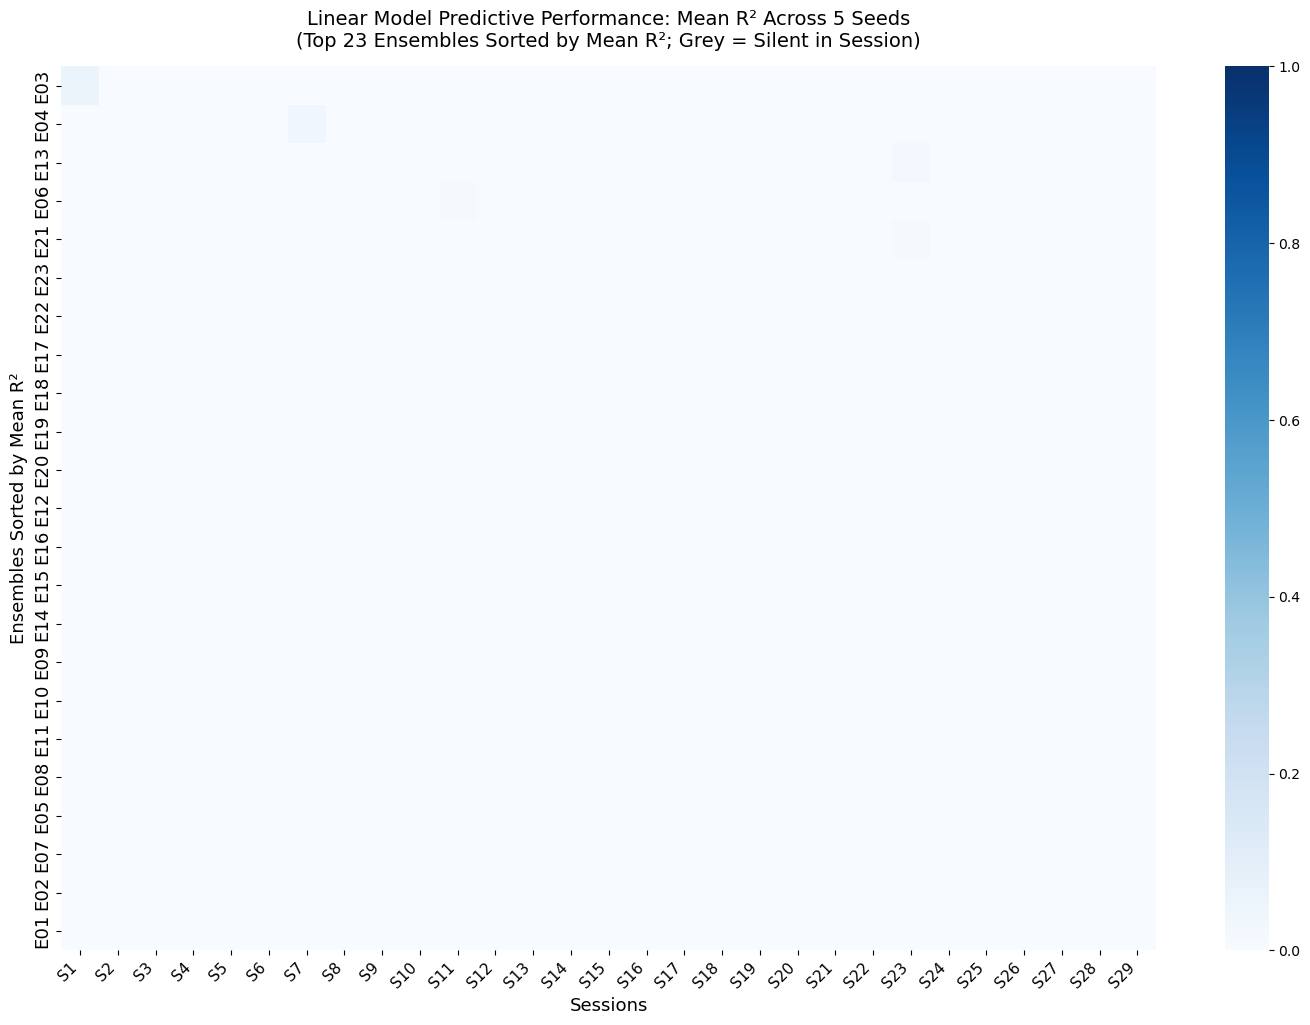

In [ ]:
# ── R² heatmap: mean across seeds (blue scale, top 30 neurons) ─────────────
NO_DATA_COLOR = '#bbbbbb'

r2_clipped  = np.clip(mean_r2, 0.0, 1.0)
neuron_mean = ma.array(r2_clipped, mask=mask).mean(axis=0).filled(np.nan)
neuron_order = np.argsort(neuron_mean)[::-1]

# Filter: exclude fully-masked sessions and neurons
session_has_data  = ~np.all(mask, axis=1)
neuron_has_data   = ~np.all(mask, axis=0)
valid_sessions    = np.where(session_has_data)[0]
valid_neurons_all = np.where(neuron_has_data)[0]

# Top-N restricted to neurons that have any data
valid_in_order = [n for n in neuron_order if n in set(valid_neurons_all)]
N_SHOW = min(30, len(valid_in_order))
top_neurons = valid_in_order[:N_SHOW]

r2_show   = r2_clipped[np.ix_(valid_sessions, top_neurons)].T
std_show  = std_r2[np.ix_(valid_sessions, top_neurons)].T
mask_show = mask[np.ix_(valid_sessions, top_neurons)].T

r2_ytick_labels = [f"{prefix_name}{n+1:02d}" for n in top_neurons]
r2_xtick_labels = [f"S{s+1}" for s in valid_sessions]

# Store for std heatmap cell (near consistency section)
r2_show_data   = r2_show
std_show_data  = std_show
mask_show_data = mask_show

n_sessions_show = len(valid_sessions)
cell_h = max(4, 0.45 * N_SHOW)
cell_w = max(6, 0.50 * n_sessions_show)

cmap_r2 = plt.cm.Blues.copy()
cmap_r2.set_bad(color=NO_DATA_COLOR)
r2_plot = r2_show.astype(float)
r2_plot[mask_show] = np.nan

fig, ax = plt.subplots(figsize=(cell_w, cell_h))
sns.heatmap(r2_plot, cmap=cmap_r2, vmin=0, vmax=1, cbar=True,
            xticklabels=r2_xtick_labels,
            yticklabels=r2_ytick_labels,
            ax=ax)
ax.set_yticklabels(r2_ytick_labels, fontsize=13)
ax.set_xticklabels(r2_xtick_labels, fontsize=11, rotation=45, ha='right')

for (i, j) in zip(*np.where(mask_show)):
    ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                hatch='////', edgecolor='#888888', lw=0.5, zorder=2))

ax.set_title(f'Linear Model Predictive Performance: Mean R² Across {len(SEEDS)} Seeds\n'
             f'(Top {N_SHOW} {unit_label_pl.capitalize()} Sorted by Mean R²; Grey = Silent in Session)',
             fontsize=14, pad=14)
ax.set_xlabel('Sessions', fontsize=13)
ax.set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean R²', fontsize=13)
plt.tight_layout()
plt.show()


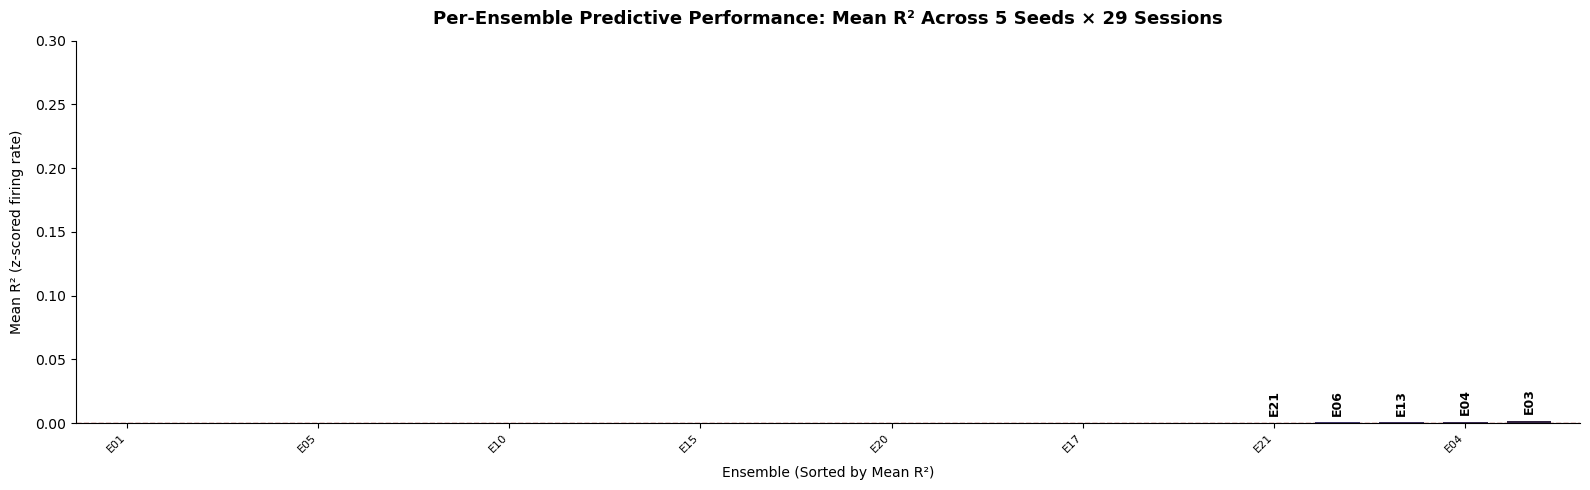

In [ ]:
# ── Per-neuron R² bar chart: mean over seeds × sessions, top-5 labeled ──────
masked_r2      = ma.array(np.clip(mean_r2, 0, 1), mask=mask)
neuron_mean_r2 = masked_r2.mean(axis=0).filled(np.nan)

order   = np.argsort(neuron_mean_r2)          # ascending: worst -> best
x       = np.arange(num_neurons)
labels  = [f"{prefix_name}{i+1:02d}" for i in order]
means_s = neuron_mean_r2[order]

palette = sns.color_palette("mako_r", as_cmap=True)
colors  = palette(np.linspace(0.15, 0.85, num_neurons))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(x, means_s, width=0.7, color=colors, zorder=3, linewidth=0)
ax.axhline(0, color='firebrick', linestyle='--', linewidth=1)

# Label top-5 neurons
top5_pos = list(range(num_neurons - 5, num_neurons))
for pos in top5_pos:
    ax.text(pos, means_s[pos] + 0.005, labels[pos],
            ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=90)

ax.set_xticks(x[::3])
ax.set_xticklabels(labels[::3], rotation=45, ha="right", fontsize=8)
ax.set_xlabel(f"{unit_label.capitalize()} (Sorted by Mean R²)", labelpad=8)
ax.set_ylabel("Mean R² (z-scored firing rate)", labelpad=8)
ax.set_title(f"Per-{unit_label.capitalize()} Predictive Performance: Mean R² Across {len(SEEDS)} Seeds × {num_sessions} Sessions",
             fontsize=13, fontweight="bold", pad=12)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.set_xlim(-0.8, num_neurons - 0.2)
ax.set_ylim(0, 0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

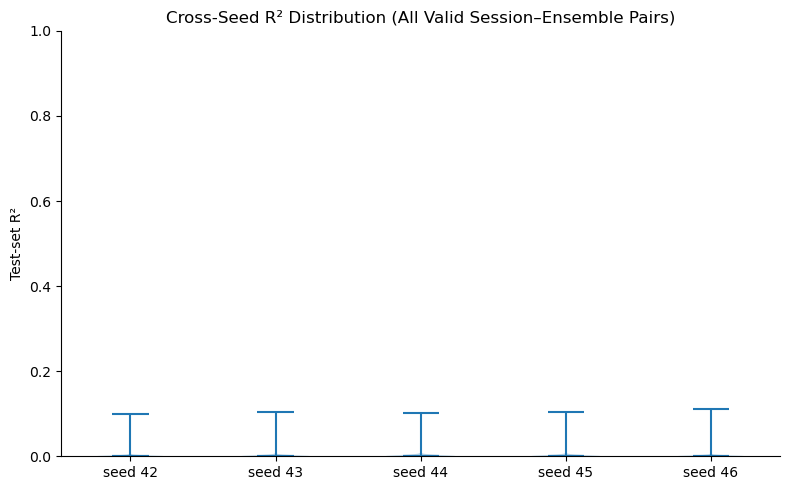

In [ ]:
# ── Per-seed R² violin ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
data_per_seed = [np.clip(all_r2[s_idx][~mask], 0, 1) for s_idx in range(len(SEEDS))]
ax.violinplot(data_per_seed, positions=range(len(SEEDS)), showmedians=True)
ax.set_xticks(range(len(SEEDS)))
ax.set_xticklabels([f"seed {s}" for s in SEEDS])
ax.set_ylabel("Test-set R²")
ax.set_title(f"Cross-Seed R² Distribution (All Valid Session–{unit_label.capitalize()} Pairs)")
ax.set_ylim(0, 1)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
# ── Permutation importance (averaged across seeds, good neurons only) ──────
n_feats = len(all_feat_cols)

if RUN_IMPORTANCE:

    # Filter at neuron level: only neurons whose mean R² across sessions meets the bar.
    # Per-session filtering would inflate scores by conditioning on success.
    neuron_mean_global = np.nanmean(np.where(mask, np.nan, mean_r2), axis=0)  # (num_neurons,)

    all_importance = np.full((len(SEEDS), num_sessions, num_neurons, n_feats), np.nan)

    for seed_idx, seed in enumerate(SEEDS):
        split_path = os.path.join(splits_dir, f"split_seed{seed}.npy")
        test_indices_by_session = np.load(split_path, allow_pickle=True).item()
        models_dir = os.path.join(models_root, f"seed{seed}")

        for test_idx, test_session in enumerate(session_ids):
            session_data   = session_dataset_singles[test_session]["data"]
            session_labels = session_dataset_singles[test_session]["labels"]
            test_idx_      = test_indices_by_session[test_session]

            test_data_np   = np.concatenate([session_data[idx]   for idx in test_idx_], axis=0).astype(np.float32)
            test_labels_np = np.concatenate([session_labels[idx] for idx in test_idx_], axis=0)

            for neuron_idx in range(num_neurons):
                if mask[test_idx, neuron_idx]:
                    continue
                if neuron_mean_global[neuron_idx] < R2_THRESHOLD:
                    continue
                if all_r2[seed_idx, test_idx, neuron_idx] < 0.1:
                    continue
                mpath = os.path.join(models_dir, f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue

                model = LinearModel(input_size, output_size).to(device)
                model.load_state_dict(torch.load(mpath, map_location=device))
                model.eval()

                with torch.no_grad():
                    _, preds = model(torch.tensor(test_data_np, dtype=torch.float32).to(device))
                    baseline_r2 = all_r2[seed_idx, test_idx, neuron_idx]

                for feat_idx in range(n_feats):
                    r2_permuted = []
                    for _ in range(N_PERM_REPEATS):
                        permuted = test_data_np.copy()
                        np.random.shuffle(permuted[:, feat_idx])
                        with torch.no_grad():
                            _, pp = model(torch.tensor(permuted, dtype=torch.float32).to(device))
                            r2_permuted.append(r2_score(test_labels_np[:, neuron_idx],
                                                        pp.squeeze().cpu().numpy()))
                    all_importance[seed_idx, test_idx, neuron_idx, feat_idx] = (
                        baseline_r2 - np.mean(r2_permuted)
                    )

                del model
                torch.cuda.empty_cache()

            del test_data_np, test_labels_np

        print(f"Seed {seed} importance done.")

    # nanmedian is more robust to outlier seeds than nanmean
    with np.errstate(all='ignore'):
        importance_matrix = np.nanmedian(all_importance, axis=0)  # (sessions, neurons, n_feats)
    np.save(os.path.join(output_dir, "importance_matrix.npy"), importance_matrix)
    print("Saved importance_matrix.npy")

Seed 42 importance done.
Seed 43 importance done.
Seed 44 importance done.
Seed 45 importance done.
Seed 46 importance done.
Saved importance_matrix.npy


/tmp/ipykernel_817931/860083931.py:66: RuntimeWarning: All-NaN slice encountered
  importance_matrix = np.nanmedian(all_importance, axis=0)  # (sessions, neurons, n_feats)


In [ ]:
# ── Reload saved importance (skip computation above if already run) ─────────
importance_matrix = np.load(os.path.join(output_dir, "importance_matrix.npy"))

# Mask neurons whose global mean R² (across sessions) is below threshold.
# Using the same neuron-level criterion as the computation loop avoids inflating
# importance scores by conditioning on per-session success.
neuron_mean_global = np.nanmean(np.where(mask, np.nan, mean_r2), axis=0)  # (num_neurons,)
low_r2_mask = neuron_mean_global < R2_THRESHOLD                            # (num_neurons,)
importance_masked = np.where(
    (mask | low_r2_mask[np.newaxis, :])[:, :, np.newaxis], np.nan, importance_matrix
)

/tmp/ipykernel_817931/3138346412.py:3: RuntimeWarning: Mean of empty slice
  feat_mean  = np.nanmean(imp_flat, axis=0)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


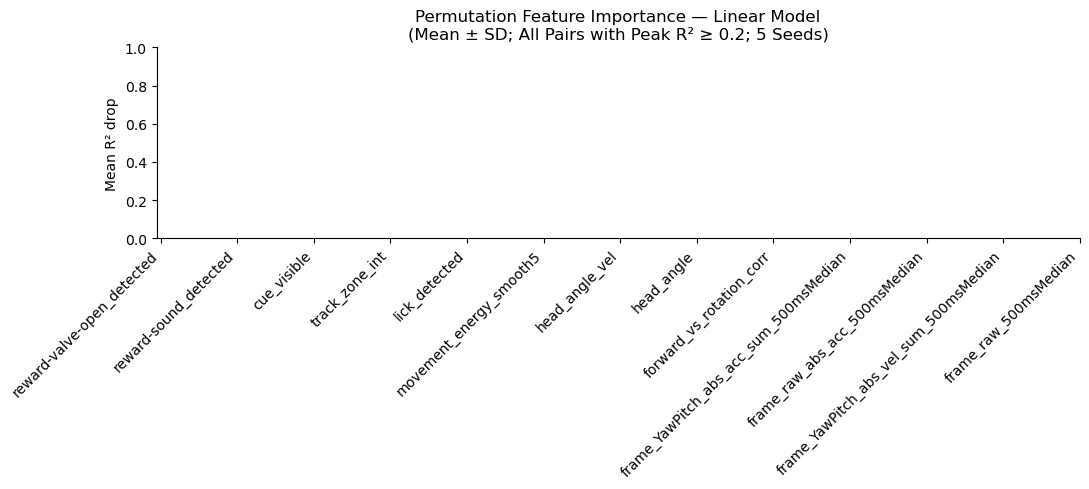

In [ ]:
# ── Feature importance bar chart ───────────────────────────────────────────
imp_flat   = importance_masked.reshape(-1, n_feats)
feat_mean  = np.nanmean(imp_flat, axis=0)
feat_std   = np.nanstd(imp_flat,  axis=0)
feat_order = np.argsort(feat_mean)[::-1]

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(n_feats)
ax.bar(x, feat_mean[feat_order], yerr=feat_std[feat_order],
       color='steelblue', capsize=4, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels([all_feat_cols[i] for i in feat_order], rotation=45, ha='right')
ax.set_ylabel('Mean R² drop')
ax.set_title(f'Permutation Feature Importance — Linear Model\n'
             f'(Mean ± SD; All Pairs with Peak R² ≥ {R2_THRESHOLD}; {len(SEEDS)} Seeds)')
ax.set_ylim(0, 1.0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

/tmp/ipykernel_817931/1549026195.py:4: RuntimeWarning: Mean of empty slice
  neuron_importance = np.nanmean(importance_masked, axis=0)  # (n_neurons, n_feats)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


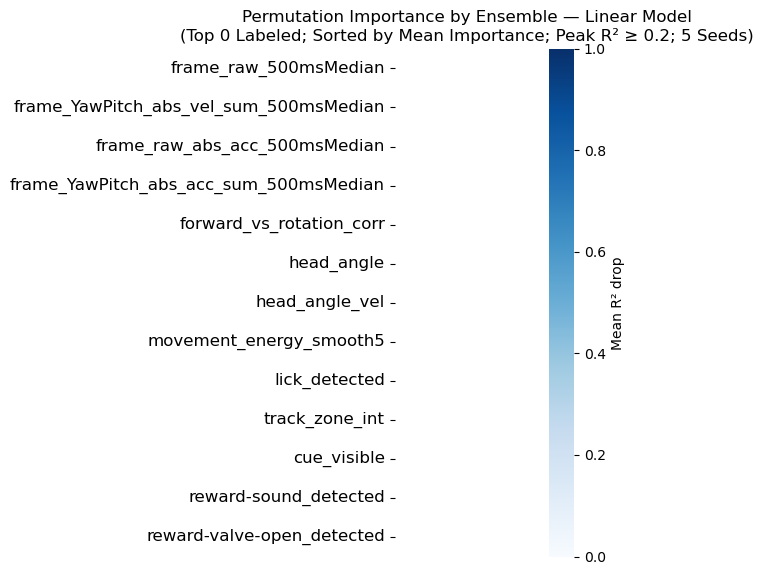

In [ ]:
# ── Importance heatmap: feature × neuron (mean over sessions, top 30) ───────
NO_DATA_COLOR = '#bbbbbb'

neuron_importance = np.nanmean(importance_masked, axis=0)  # (n_neurons, n_feats)
valid_neurons     = ~np.all(np.isnan(neuron_importance), axis=1)

hm_data       = neuron_importance[valid_neurons, :].T
neuron_labels = [f"{prefix_name}{n+1:02d}" for n in np.where(valid_neurons)[0]]
order_n       = np.argsort(np.nanmean(hm_data, axis=0))[::-1]
hm_data       = hm_data[:, order_n]
neuron_labels = [neuron_labels[i] for i in order_n]

N_SHOW_IMP  = min(30, len(neuron_labels))
hm_data     = hm_data[:, :N_SHOW_IMP]
neuron_labels = neuron_labels[:N_SHOW_IMP]

cell_h_imp = max(4, 0.45 * n_feats)
cell_w_imp = max(6, 0.45 * N_SHOW_IMP)

cmap_imp = plt.cm.Blues.copy()
cmap_imp.set_bad(color=NO_DATA_COLOR)

fig, ax = plt.subplots(figsize=(cell_w_imp, cell_h_imp))
sns.heatmap(hm_data, cmap=cmap_imp, ax=ax, vmin=0, vmax=1.0, cbar_kws={'label': 'Mean R² drop'},
            xticklabels=neuron_labels, yticklabels=all_feat_cols)
ax.set_yticklabels(all_feat_cols, fontsize=12)
ax.set_xticklabels(neuron_labels, rotation=45, ha='right', fontsize=12)
ax.set_title(f'Permutation Importance by {unit_label.capitalize()} — Linear Model\n'
             f'(Top {N_SHOW_IMP} Labeled; Sorted by Mean Importance; Peak R² ≥ {R2_THRESHOLD}; {len(SEEDS)} Seeds)')
plt.tight_layout()
plt.show()


In [ ]:
# ── Importance heatmap: feature × session-neuron pair (top 30) ───────────
NO_DATA_COLOR = '#bbbbbb'

pair_labels, imp_cols = [], []
for s in range(num_sessions):
    for n in range(num_neurons):
        row = importance_masked[s, n, :]
        if not np.all(np.isnan(row)):
            pair_labels.append(f"S{s+1:02d}·{prefix_name}{n+1:02d}")
            imp_cols.append(row)

if not imp_cols:
    print(f"No pairs with R² ≥ {R2_THRESHOLD}")
else:
    hm_data     = np.array(imp_cols).T
    order_p     = np.argsort(np.nanmean(hm_data, axis=0))[::-1]
    hm_data     = hm_data[:, order_p]
    pair_labels = [pair_labels[i] for i in order_p]

    N_SHOW_PAIR = min(30, len(pair_labels))
    hm_data     = hm_data[:, :N_SHOW_PAIR]
    pair_labels = pair_labels[:N_SHOW_PAIR]

    cell_h_p = max(4, 0.45 * n_feats)
    cell_w_p = max(6, 0.45 * N_SHOW_PAIR)

    cmap_pair = plt.cm.Blues.copy()
    cmap_pair.set_bad(color=NO_DATA_COLOR)

    fig, ax = plt.subplots(figsize=(cell_w_p, cell_h_p))
    sns.heatmap(hm_data, cmap=cmap_pair, ax=ax, vmin=0, vmax=1.0, cbar_kws={'label': 'R² drop'},
                xticklabels=pair_labels, yticklabels=all_feat_cols)
    ax.set_yticklabels(all_feat_cols, fontsize=12)
    ax.set_xticklabels(pair_labels, rotation=45, ha='right', fontsize=10)
    ax.set_title(f'Permutation Importance by Session–{unit_label.capitalize()} Pair\n'
                 f'(Top {N_SHOW_PAIR} Pairs with Peak R² ≥ {R2_THRESHOLD}; Sorted by Mean Importance)')
    plt.tight_layout()
    plt.show()


No pairs with R² ≥ 0.2


In [ ]:
# ── Weight vector consistency across seeds ─────────────────────────────────
# LinearModel has a single fc layer: weight shape (1, 13), bias shape (1).
# For each (session, neuron) pair with mean_r2 >= CONSISTENCY_THRESHOLD we load
# the weight vector from all seeds and compute pairwise Pearson r.
# r ≈ 1 means all seeds found the same feature weighting.

def pairwise_pearson(vecs):
    scores = []
    for i, j in itertools.combinations(range(len(vecs)), 2):
        r, _ = pearsonr(vecs[i], vecs[j])
        scores.append(r)
    return np.array(scores)


if RUN_CONSISTENCY:
    weight_corr_matrix = np.full((num_sessions, num_neurons), np.nan)

    for test_idx, test_session in enumerate(session_ids):
        for neuron_idx in range(num_neurons):
            if mask[test_idx, neuron_idx]:
                continue
            if mean_r2[test_idx, neuron_idx] < CONSISTENCY_THRESHOLD:
                continue

            weight_vecs = []
            for seed in SEEDS:
                mpath = os.path.join(models_root, f"seed{seed}",
                                     f"session_{test_idx:02d}_neuron_{neuron_idx:02d}.pt")
                if not os.path.exists(mpath):
                    continue
                sd = torch.load(mpath, map_location='cpu')
                w  = sd['fc.weight'].squeeze().numpy()   # (13,)
                weight_vecs.append(w)

            if len(weight_vecs) >= 2:
                scores = pairwise_pearson(weight_vecs)
                weight_corr_matrix[test_idx, neuron_idx] = scores.mean()

    np.save(os.path.join(output_dir, "weight_corr_matrix.npy"), weight_corr_matrix)
    print(f"Saved weight_corr_matrix.npy")
    print(f"Mean weight correlation (good {unit_label_pl}): {np.nanmean(weight_corr_matrix[~mask]):.3f}")


Saved weight_corr_matrix.npy
Mean weight correlation (good ensembles): nan


/tmp/ipykernel_817931/1257531963.py:41: RuntimeWarning: Mean of empty slice
  print(f"Mean weight correlation (good {unit_label_pl}): {np.nanmean(weight_corr_matrix[~mask]):.3f}")


In [ ]:
# ── Reload saved weight consistency (skip computation above if already run) ─
weight_corr_matrix = np.load(os.path.join(output_dir, "weight_corr_matrix.npy"))
print(f"Mean weight Pearson r (good {unit_label_pl}): {np.nanmean(weight_corr_matrix[~mask]):.3f}")

Mean weight Pearson r (good ensembles): nan


/tmp/ipykernel_817931/257068199.py:3: RuntimeWarning: Mean of empty slice
  print(f"Mean weight Pearson r (good {unit_label_pl}): {np.nanmean(weight_corr_matrix[~mask]):.3f}")


/tmp/ipykernel_817931/388049332.py:10: RuntimeWarning: Mean of empty slice
  wc_mean  = np.nanmean(weight_corr_matrix, axis=0)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


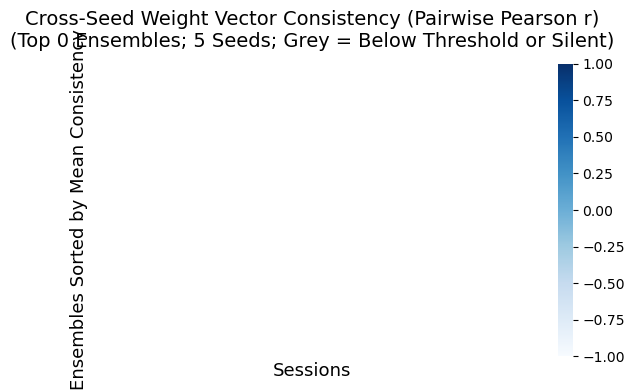

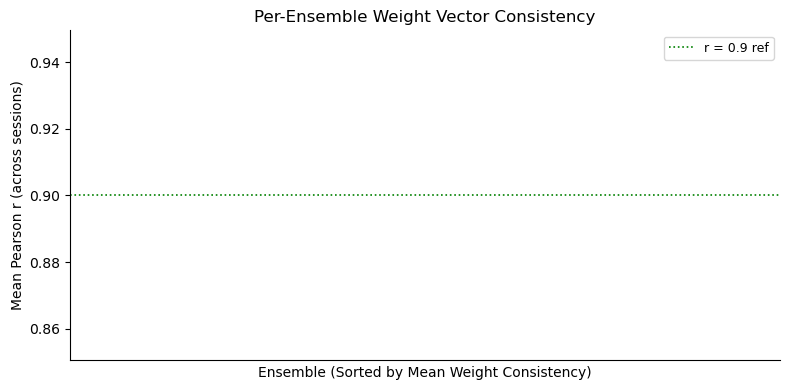

In [ ]:
# ── Weight consistency heatmap (blue scale, top 30) ─────────────────────────
NO_DATA_COLOR = '#bbbbbb'

# Filter: exclude sessions/neurons with no consistency data
wc_session_has_data = ~np.all(np.isnan(weight_corr_matrix), axis=1)
wc_neuron_has_data  = ~np.all(np.isnan(weight_corr_matrix), axis=0)
wc_valid_sessions   = np.where(wc_session_has_data)[0]
wc_valid_neurons    = np.where(wc_neuron_has_data)[0]

wc_mean  = np.nanmean(weight_corr_matrix, axis=0)
wc_order = np.argsort(wc_mean)[::-1]
valid_in_wc_order = [n for n in wc_order if n in set(wc_valid_neurons)]
N_SHOW_WC = min(30, len(valid_in_wc_order))
top_wc_neurons = valid_in_wc_order[:N_SHOW_WC]

wc_show  = weight_corr_matrix[np.ix_(wc_valid_sessions, top_wc_neurons)].T
mask_wc  = np.isnan(wc_show)
wc_yticks = [f"{prefix_name}{n+1:02d}" for n in top_wc_neurons]
wc_xticks = [f"S{s+1}" for s in wc_valid_sessions]

cell_h_wc = max(4, 0.45 * N_SHOW_WC)
cell_w_wc = max(6, 0.50 * len(wc_valid_sessions))

cmap_wc = plt.cm.Blues.copy()
cmap_wc.set_bad(color=NO_DATA_COLOR)
wc_plot = wc_show.astype(float)

fig, ax = plt.subplots(figsize=(cell_w_wc, cell_h_wc))
sns.heatmap(wc_plot, cmap=cmap_wc, vmin=-1, vmax=1, cbar=True,
            xticklabels=wc_xticks, yticklabels=wc_yticks, ax=ax)
ax.set_yticklabels(wc_yticks, fontsize=13)
ax.set_xticklabels(wc_xticks, fontsize=11, rotation=45, ha='right')

for (i, j) in zip(*np.where(mask_wc)):
    ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                hatch='////', edgecolor='#888888', lw=0.5, zorder=2))

ax.set_title(f'Cross-Seed Weight Vector Consistency (Pairwise Pearson r)\n'
             f'(Top {N_SHOW_WC} {unit_label_pl.capitalize()}; {len(SEEDS)} Seeds; Grey = Below Threshold or Silent)',
             fontsize=14, pad=12)
ax.set_xlabel('Sessions', fontsize=13)
ax.set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean Consistency', fontsize=13)
plt.tight_layout()
plt.show()

# Per-neuron bar chart (filtered to neurons with any valid consistency data)
valid_idx = np.where(wc_neuron_has_data)[0]
order_bar = valid_idx[np.argsort(wc_mean[valid_idx])]

fig, ax = plt.subplots(figsize=(max(8, len(valid_idx) * 0.35), 4))
ax.bar(range(len(order_bar)), wc_mean[order_bar],
       color='steelblue', alpha=0.75, width=0.75)
ax.axhline(0.9, color='green', linestyle=':', lw=1.2, label='r = 0.9 ref')
ax.set_xticks(range(len(order_bar)))
ax.set_xticklabels([f"{prefix_name}{n+1:02d}" for n in order_bar],
                   rotation=45, ha='right', fontsize=8)
ax.set_xlabel(f'{unit_label.capitalize()} (Sorted by Mean Weight Consistency)')
ax.set_ylabel('Mean Pearson r (across sessions)')
ax.set_title(f'Per-{unit_label.capitalize()} Weight Vector Consistency')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()


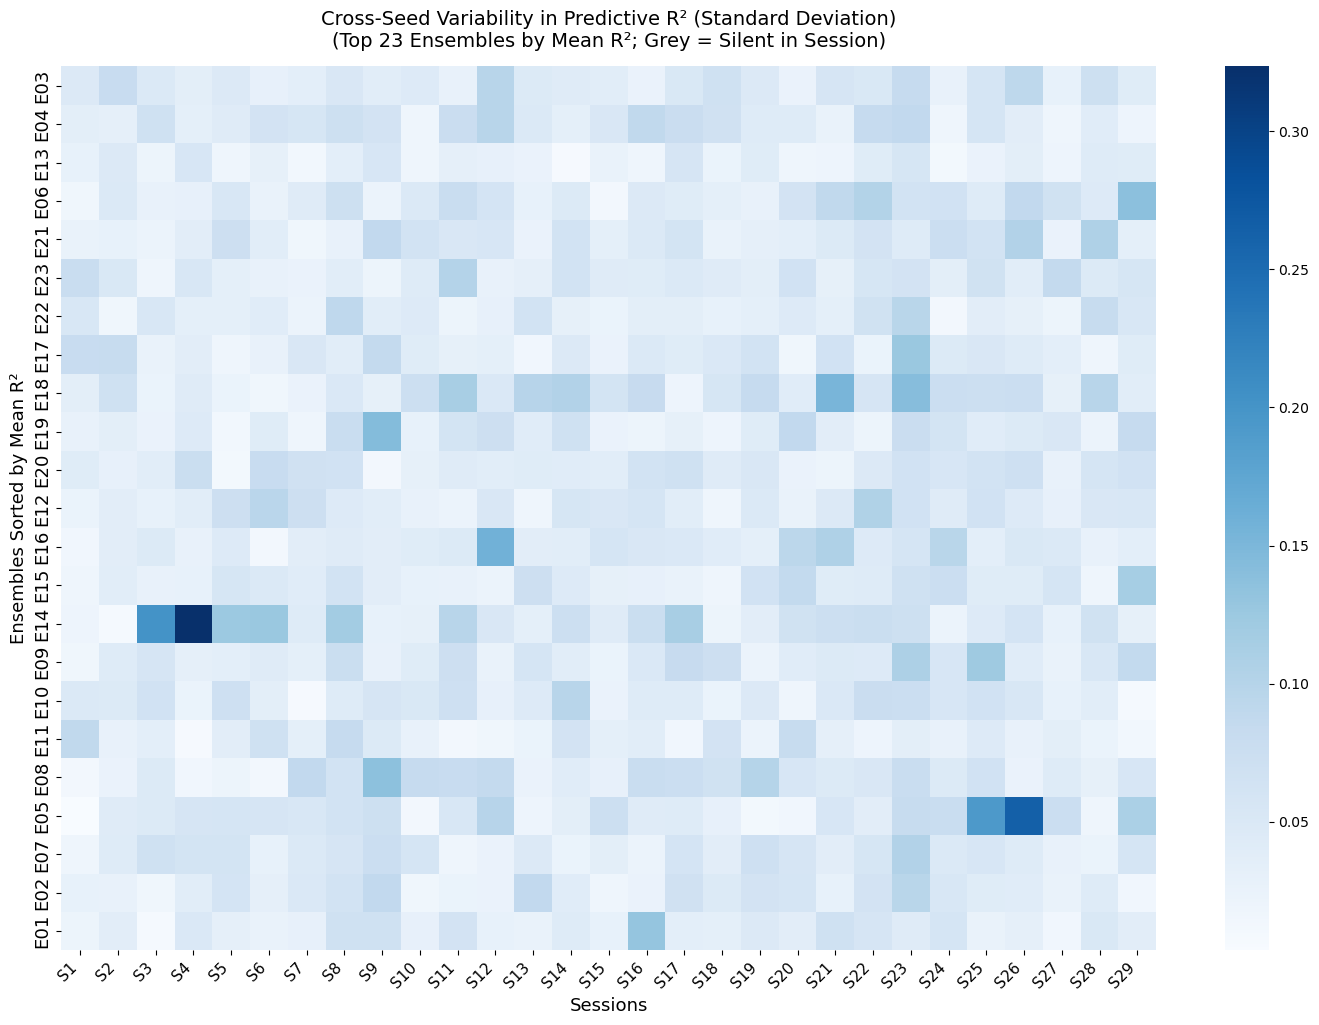

In [ ]:
# ── Seed R² std heatmap (blue scale, near consistency section) ──────────────
# Reuses top-30 selection computed in the Mean R² heatmap cell.
NO_DATA_COLOR = '#bbbbbb'

cmap_std = plt.cm.Blues.copy()
cmap_std.set_bad(color=NO_DATA_COLOR)
std_plot = std_show_data.astype(float)
std_plot[mask_show_data] = np.nan

cell_h_s = max(4, 0.45 * std_show_data.shape[0])
cell_w_s = max(6, 0.50 * std_show_data.shape[1])

fig, ax = plt.subplots(figsize=(cell_w_s, cell_h_s))
sns.heatmap(std_plot, cmap=cmap_std, cbar=True,
            xticklabels=r2_xtick_labels,
            yticklabels=r2_ytick_labels,
            ax=ax)
ax.set_yticklabels(r2_ytick_labels, fontsize=13)
ax.set_xticklabels(r2_xtick_labels, fontsize=11, rotation=45, ha='right')

for (i, j) in zip(*np.where(mask_show_data)):
    ax.add_patch(plt.Rectangle([j, i], 1, 1, fill=True, facecolor=NO_DATA_COLOR,
                                hatch='////', edgecolor='#888888', lw=0.5, zorder=2))

ax.set_title(f'Cross-Seed Variability in Predictive R² (Standard Deviation)\n'
             f'(Top {std_show_data.shape[0]} {unit_label_pl.capitalize()} by Mean R²; Grey = Silent in Session)',
             fontsize=14, pad=14)
ax.set_xlabel('Sessions', fontsize=13)
ax.set_ylabel(f'{unit_label_pl.capitalize()} Sorted by Mean R²', fontsize=13)
plt.tight_layout()
plt.show()


/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/_core/_methods.py:145: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_817931/3274043166.py:12: RuntimeWarning: Mean of empty slice
  f'(n = {len(valid_wc)},  mean = {np.nanmean(valid_wc):.3f},  sd = {np.nanstd(valid_wc):.3f})')
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


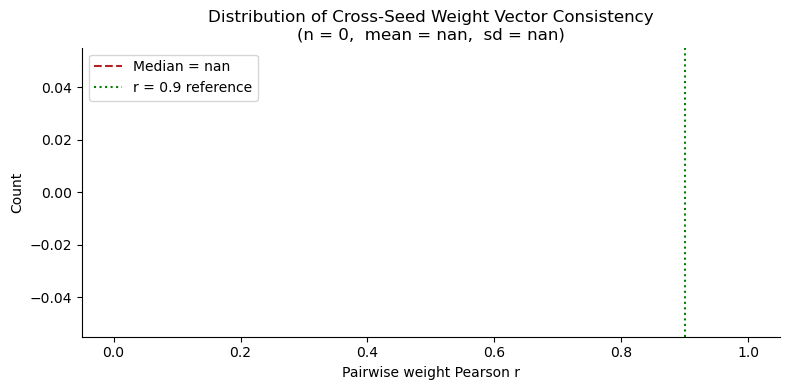

In [ ]:
# ── Distribution of weight consistency ────────────────────────────────────
valid_wc = weight_corr_matrix[~mask & np.isfinite(weight_corr_matrix)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(valid_wc, bins=40, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(np.median(valid_wc), color='firebrick', lw=1.5, linestyle='--',
           label=f'Median = {np.median(valid_wc):.3f}')
ax.axvline(0.9, color='green', lw=1.5, linestyle=':', label='r = 0.9 reference')
ax.set_xlabel('Pairwise weight Pearson r')
ax.set_ylabel('Count')
ax.set_title(f'Distribution of Cross-Seed Weight Vector Consistency\n'
             f'(n = {len(valid_wc)},  mean = {np.nanmean(valid_wc):.3f},  sd = {np.nanstd(valid_wc):.3f})')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:552: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:3037: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
/home/amitsant2000/miniconda3/envs/analysisVR/lib/python3.10/site-packages/numpy/lib/_function_base_impl.py:2894: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


TypeError: expected non-empty vector for x

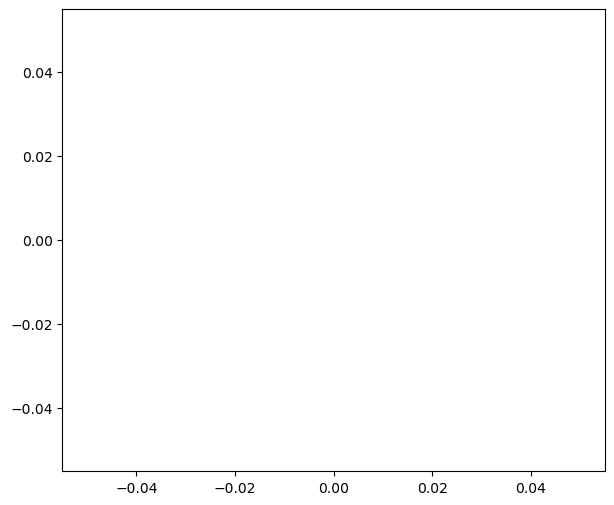

In [ ]:
# ── Predictive R² vs weight consistency scatter ───────────────────────────
valid  = ~mask & np.isfinite(weight_corr_matrix)
wc_f   = weight_corr_matrix[valid]
r2_f   = np.clip(mean_r2, 0, 1)[valid]
finite = np.isfinite(wc_f) & np.isfinite(r2_f)
wc_f, r2_f = wc_f[finite], r2_f[finite]

r_pearson = np.corrcoef(r2_f, wc_f)[0, 1]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(r2_f, wc_f, alpha=0.15, s=8, color='steelblue')
m, b = np.polyfit(r2_f, wc_f, 1)
x_line = np.linspace(r2_f.min(), r2_f.max(), 200)
ax.plot(x_line, m * x_line + b, color='firebrick', lw=1.5, label=f'r = {r_pearson:.2f}')
ax.axhline(0.9, color='green', linestyle=':', lw=1, label='Weight consistency = 0.9')
ax.set_xlabel('Mean test-set R² (averaged across seeds × sessions)')
ax.set_ylabel('Weight vector consistency (Pearson r, across seeds)')
ax.set_title(f'Predictive Performance vs. Weight Vector Consistency\n'
             f'(Each Point = One Session–{unit_label.capitalize()} Pair;  r = {r_pearson:.2f})')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()